# Exploratory Data Analysis: IEEE-CIS Fraud Detection

This notebook explores the IEEE-CIS Fraud Detection dataset published by Vesta Corporation.
The goal is to understand the data distribution, identify fraud patterns, and motivate
the feature engineering decisions made in features.py.

**Dataset:** 590,540 transactions across 6 months, 394 raw features, 3.5% fraud rate.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries loaded.')


Libraries loaded.


## 1. Data Loading

The dataset comes in two files that join on TransactionID.
The transaction file contains payment details and anonymized features.
The identity file contains device and browser information and is only
available for a subset of transactions.


In [3]:
print('Loading data...')
train_txn = pd.read_csv('../data/train_transaction.csv')
train_id  = pd.read_csv('../data/train_identity.csv')

train = train_txn.merge(train_id, on='TransactionID', how='left')

print(f'Transaction file : {train_txn.shape[0]:,} rows  {train_txn.shape[1]} cols')
print(f'Identity file    : {train_id.shape[0]:,} rows  {train_id.shape[1]} cols')
print(f'Merged dataset   : {train.shape[0]:,} rows  {train.shape[1]} cols')
print(f'\nFraud cases : {train.isFraud.sum():,}  ({train.isFraud.mean()*100:.2f}%)')
print(f'Legit cases : {(train.isFraud==0).sum():,}  ({(1-train.isFraud.mean())*100:.2f}%)')


Loading data...
Transaction file : 590,540 rows  394 cols
Identity file    : 144,233 rows  41 cols
Merged dataset   : 590,540 rows  434 cols

Fraud cases : 20,663  (3.50%)
Legit cases : 569,877  (96.50%)


## 2. Missing Values

Many features in this dataset have very high missing rates. Features missing more than 90%
of their values carry almost no signal and are dropped during feature engineering.
Understanding the missing value structure also helps identify which V columns belong
to the same transaction type group since they tend to go missing together.


Columns with any missing value : 382
Columns with >90% missing      : 12
Columns with >50% missing      : 214
Columns with >20% missing      : 252

Top 20 most missing columns:
id_24   99.20
id_08   99.10
id_07   99.10
id_23   99.10
id_26   99.10
id_22   99.10
id_27   99.10
id_21   99.10
id_25   99.10
dist2   93.60
D7      93.40
id_18   92.40
D14     89.50
D13     89.50
D12     89.00
id_03   88.80
id_04   88.80
id_33   87.60
D6      87.60
D9      87.30


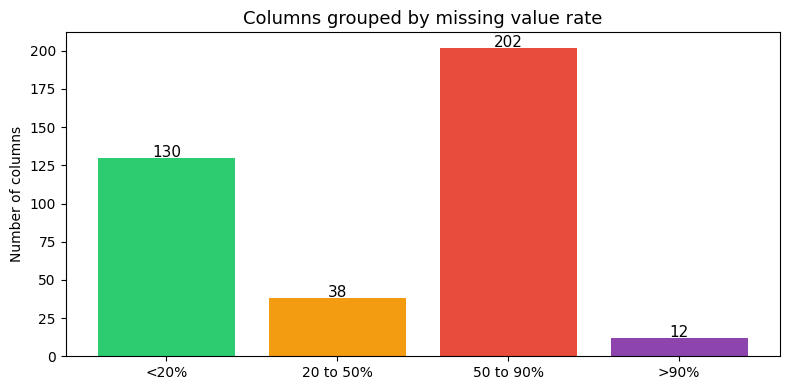

In [4]:
missing = (train.isnull().sum() / len(train) * 100).round(1)
missing = missing[missing > 0].sort_values(ascending=False)

print(f'Columns with any missing value : {len(missing)}')
print(f'Columns with >90% missing      : {(missing > 90).sum()}')
print(f'Columns with >50% missing      : {(missing > 50).sum()}')
print(f'Columns with >20% missing      : {(missing > 20).sum()}')
print(f'\nTop 20 most missing columns:')
print(missing.head(20).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
buckets = [0, 20, 50, 90, 100]
labels  = ['<20%', '20 to 50%', '50 to 90%', '>90%']
counts  = [((missing > buckets[i]) & (missing <= buckets[i+1])).sum() for i in range(4)]
colors  = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
ax.bar(labels, counts, color=colors)
ax.set_title('Columns grouped by missing value rate', fontsize=13)
ax.set_ylabel('Number of columns')
for i, v in enumerate(counts):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()


## 3. Class Imbalance

The dataset has a severe class imbalance: only 3.5% of transactions are fraudulent.
This 27.5:1 ratio (legit to fraud) is the core challenge of the modeling problem.
A naive classifier that labels everything as legitimate would achieve 96.5% accuracy
while catching zero fraud. This is why AUC is used as the evaluation metric rather
than accuracy, and why scale_pos_weight is set to 27.5 during LightGBM training.


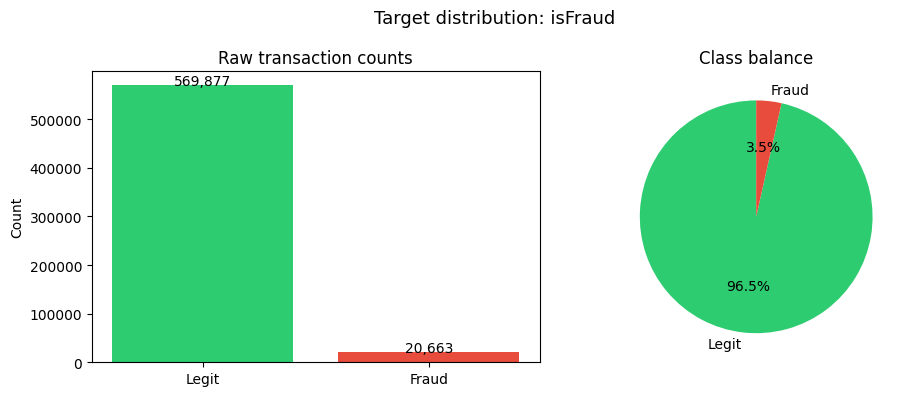

Class imbalance ratio: 27.6 to 1  (legit to fraud)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = train.isFraud.value_counts()
axes[0].bar(['Legit', 'Fraud'], counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Raw transaction counts')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center')

axes[1].pie(counts.values, labels=['Legit', 'Fraud'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Class balance')

plt.suptitle('Target distribution: isFraud', fontsize=13)
plt.tight_layout()
plt.show()

print('Class imbalance ratio:', round(counts[0] / counts[1], 1), 'to 1  (legit to fraud)')


## 4. Transaction Amount

Fraud and legitimate transactions show different amount distributions.
Fraud transactions tend to cluster at specific price points, particularly
under $200. The log scale is used because the raw distribution is heavily
right-skewed with outliers above $10,000.

This analysis motivated the amt_log feature (log transform of amount) and
the amt_z_score_card feature (how many standard deviations the amount
deviates from that specific card's historical average).


=== Transaction Amount ===
Overall  mean : \$    135.03   median : \$     68.77
Fraud    mean : \$    149.24   median : \$     75.00
Legit    mean : \$    134.51   median : \$     68.50

Min: \$0.25   Max: \$31937.39


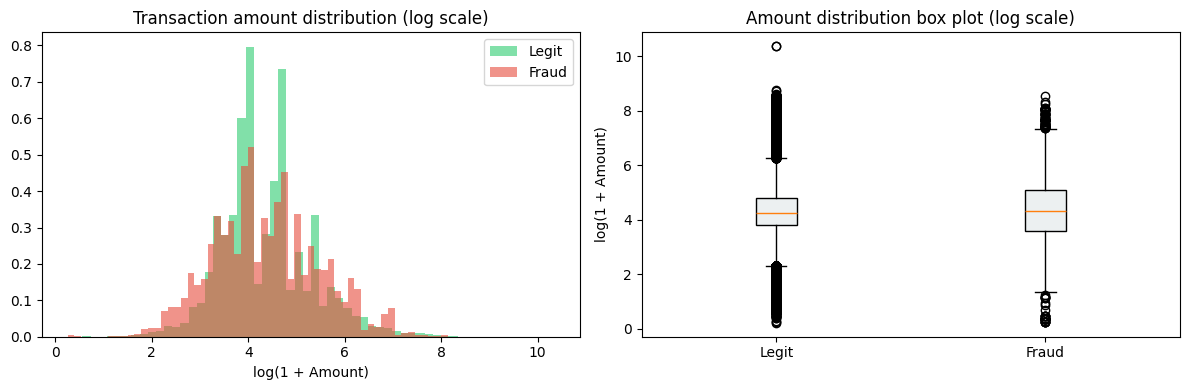

In [6]:
fraud = train[train.isFraud == 1]
legit = train[train.isFraud == 0]

print('=== Transaction Amount ===')
print(f'Overall  mean : \${train.TransactionAmt.mean():>10.2f}   median : \${train.TransactionAmt.median():>10.2f}')
print(f'Fraud    mean : \${fraud.TransactionAmt.mean():>10.2f}   median : \${fraud.TransactionAmt.median():>10.2f}')
print(f'Legit    mean : \${legit.TransactionAmt.mean():>10.2f}   median : \${legit.TransactionAmt.median():>10.2f}')
print(f'\nMin: \${train.TransactionAmt.min():.2f}   Max: \${train.TransactionAmt.max():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(np.log1p(legit.TransactionAmt), bins=60, alpha=0.6,
             color='#2ecc71', label='Legit', density=True)
axes[0].hist(np.log1p(fraud.TransactionAmt), bins=60, alpha=0.6,
             color='#e74c3c', label='Fraud', density=True)
axes[0].set_title('Transaction amount distribution (log scale)')
axes[0].set_xlabel('log(1 + Amount)')
axes[0].legend()

axes[1].boxplot([np.log1p(legit.TransactionAmt), np.log1p(fraud.TransactionAmt)],
                labels=['Legit', 'Fraud'], patch_artist=True,
                boxprops=dict(facecolor='#ecf0f1'))
axes[1].set_title('Amount distribution box plot (log scale)')
axes[1].set_ylabel('log(1 + Amount)')

plt.tight_layout()
plt.show()


## 5. Time Patterns

TransactionDT is a timedelta in seconds from a reference point, not an actual timestamp.
We extract hour of day and day of week from it.

The most striking finding: fraud rate peaks sharply at 7am (10.6%) while transaction
volume is at its lowest. Fraudsters appear to exploit the early morning window when
automated monitoring systems have fewer transactions to flag and human review teams
are not yet active. This directly motivated the hour and is_night features.


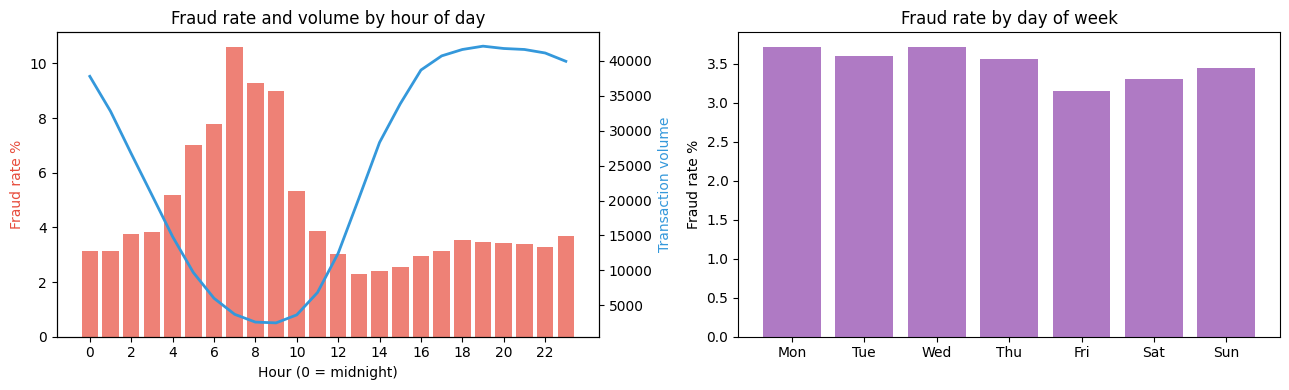

Highest fraud hour: 7 (10.61%)
Lowest  fraud hour: 13 (2.29%)


In [7]:
train['hour'] = (train.TransactionDT / 3600).astype(int) % 24
train['day']  = (train.TransactionDT / 86400).astype(int) % 7

fraud_by_hour = train.groupby('hour')['isFraud'].mean() * 100
fraud_by_day  = train.groupby('day')['isFraud'].mean()  * 100
vol_by_hour   = train.groupby('hour').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax2 = axes[0].twinx()
axes[0].bar(fraud_by_hour.index, fraud_by_hour.values, color='#e74c3c', alpha=0.7, label='Fraud rate %')
ax2.plot(vol_by_hour.index, vol_by_hour.values, color='#3498db', linewidth=2, label='Volume')
axes[0].set_title('Fraud rate and volume by hour of day')
axes[0].set_xlabel('Hour (0 = midnight)')
axes[0].set_ylabel('Fraud rate %', color='#e74c3c')
ax2.set_ylabel('Transaction volume', color='#3498db')
axes[0].set_xticks(range(0, 24, 2))

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(range(7), fraud_by_day.values, color='#9b59b6', alpha=0.8)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_labels)
axes[1].set_title('Fraud rate by day of week')
axes[1].set_ylabel('Fraud rate %')

plt.tight_layout()
plt.show()

print('Highest fraud hour:', fraud_by_hour.idxmax(), f'({fraud_by_hour.max():.2f}%)')
print('Lowest  fraud hour:', fraud_by_hour.idxmin(), f'({fraud_by_hour.min():.2f}%)')


## 6. Product Code

ProductCD categorizes the type of product or service being purchased.
Fraud rates vary significantly by product type, suggesting that certain
product categories attract more fraudulent activity.


=== Fraud rate by Product Code ===
ProductCD  count  fraud_rate  fraud_rate_pct
        C  68519        0.12           11.69
        S  11628        0.06            5.90
        H  33024        0.05            4.77
        R  37699        0.04            3.78
        W 439670        0.02            2.04


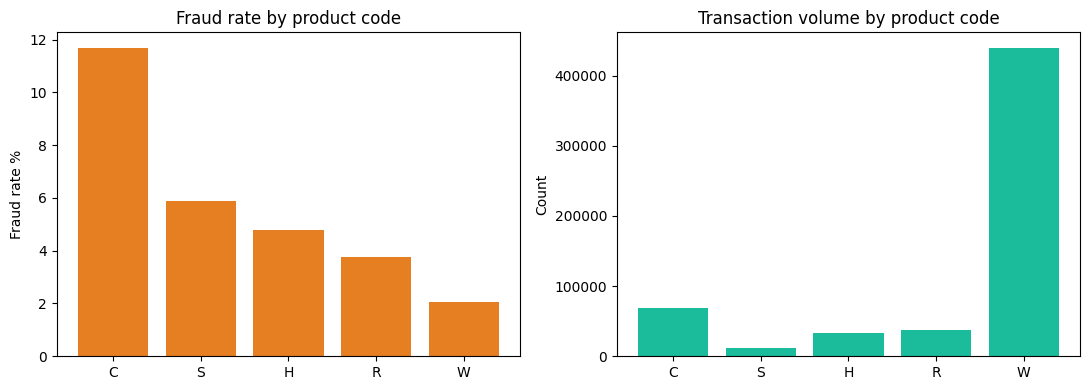

In [8]:
prod = train.groupby('ProductCD')['isFraud'].agg(['count', 'mean']).reset_index()
prod.columns = ['ProductCD', 'count', 'fraud_rate']
prod['fraud_rate_pct'] = (prod['fraud_rate'] * 100).round(2)
prod = prod.sort_values('fraud_rate_pct', ascending=False)

print('=== Fraud rate by Product Code ===')
print(prod.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(prod.ProductCD, prod.fraud_rate_pct, color='#e67e22')
axes[0].set_title('Fraud rate by product code')
axes[0].set_ylabel('Fraud rate %')

axes[1].bar(prod.ProductCD, prod['count'], color='#1abc9c')
axes[1].set_title('Transaction volume by product code')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


## 7. Card Features

Card network (card4) and card type (card6) both show meaningful variation in fraud rates.
Discover cards have the highest fraud rate at 7.7% while American Express is the lowest
at 2.9%. This likely reflects differences in verification standards across networks.
Credit cards show higher fraud rates than debit cards, consistent with the fact that
credit card details are more valuable on the black market since they allow spending
without immediate account drain.


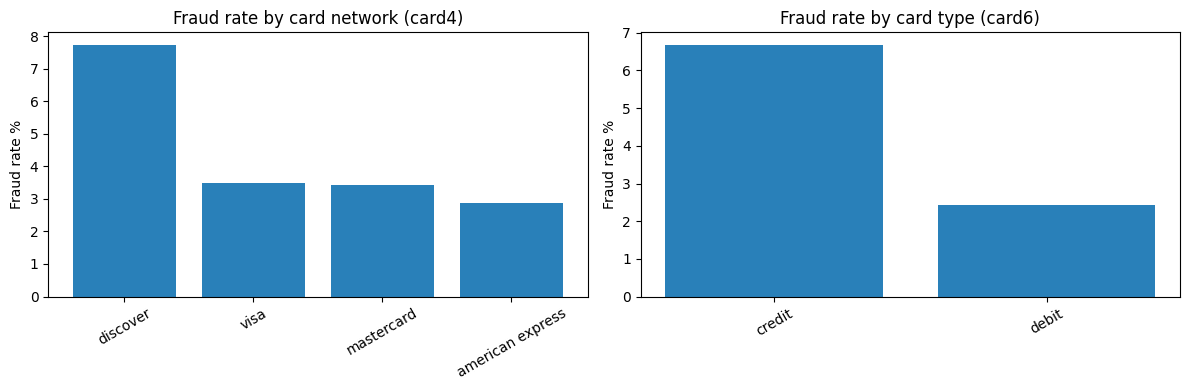

=== card4 network ===
                   count  fraud_pct
card4                              
discover            6651       7.73
visa              384767       3.48
mastercard        189217       3.43
american express    8328       2.87

=== card6 type ===
                  count  fraud_pct
card6                             
credit           148986       6.68
debit            439938       2.43
charge card          15       0.00
debit or credit      30       0.00


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(axes,
                          ['card4', 'card6'],
                          ['Fraud rate by card network (card4)',
                           'Fraud rate by card type (card6)']):
    stats = train.groupby(col)['isFraud'].agg(['count', 'mean']).reset_index()
    stats = stats[stats['count'] > 100].sort_values('mean', ascending=False)
    ax.bar(stats[col].astype(str), stats['mean'] * 100, color='#2980b9')
    ax.set_title(title)
    ax.set_ylabel('Fraud rate %')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('=== card4 network ===')
print(train.groupby('card4')['isFraud'].agg(['count', 'mean'])
      .assign(fraud_pct=lambda x: (x['mean'] * 100).round(2))
      .drop('mean', axis=1).sort_values('fraud_pct', ascending=False).to_string())

print('\n=== card6 type ===')
print(train.groupby('card6')['isFraud'].agg(['count', 'mean'])
      .assign(fraud_pct=lambda x: (x['mean'] * 100).round(2))
      .drop('mean', axis=1).sort_values('fraud_pct', ascending=False).to_string())


## 8. Email Domains

Email domain is one of the strongest categorical fraud signals in the dataset.
mail.com shows a fraud rate of 18.9%, nearly five times the dataset average of 3.5%.
Several less common domains like outlook.es and aim.com also appear disproportionately
in fraud transactions.

This finding motivated using target encoding for email domains (replacing domain strings
with their historical fraud rates from the training set) as a feature engineering step.


In [10]:
for col in ['P_emaildomain', 'R_emaildomain']:
    stats = train.groupby(col)['isFraud'].agg(['count', 'mean']).reset_index()
    stats = stats[stats['count'] > 200].sort_values('mean', ascending=False)
    stats['fraud_pct'] = (stats['mean'] * 100).round(2)
    print(f'=== {col} top 10 by fraud rate (min 200 transactions) ===')
    display_col = col
    print(stats[[display_col, 'count', 'fraud_pct']].head(10).to_string(index=False))
    print()


=== P_emaildomain top 10 by fraud rate (min 200 transactions) ===
 P_emaildomain  count  fraud_pct
      mail.com    559      18.96
    outlook.es    438      13.01
       aim.com    315      12.70
   outlook.com   5096       9.46
    hotmail.es    305       6.56
   live.com.mx    749       5.47
   hotmail.com  45250       5.30
     gmail.com 228355       4.35
embarqmail.com    260       3.46
       mac.com    436       3.21

=== R_emaildomain top 10 by fraud rate (min 200 transactions) ===
R_emaildomain  count  fraud_pct
  outlook.com   2507      16.51
   outlook.es    433      13.16
   icloud.com   1398      12.88
    gmail.com  57147      11.92
  hotmail.com  27509       7.78
   hotmail.es    292       6.85
  live.com.mx    754       5.84
    yahoo.com  11842       5.15
     live.com    762       4.99
    ymail.com    207       3.86



## 9. D Columns: Timedelta Features

The D columns represent timedelta features, days elapsed since various events
related to the card or account. The community has determined through reverse
engineering that D1 most likely represents days since the card was first used.

D1 is the most predictive D column and shows a striking pattern: fraud transactions
are heavily concentrated at D1 = 0, meaning stolen cards are almost always used
immediately after compromise. A card that has been used for hundreds of days is
far less likely to be involved in fraud.

This directly motivated the card_age feature (D1 mapped to days) and the
is_new_card binary feature (card_age < 30).


D columns available: ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15']

D column correlation with isFraud (absolute):
D8    0.14
D7    0.13
D2    0.08
D15   0.08
D10   0.07
D4    0.07
D1    0.07
D5    0.06
D13   0.06
D6    0.06
D3    0.05
D11   0.05
D9    0.04
D12   0.03
D14   0.01


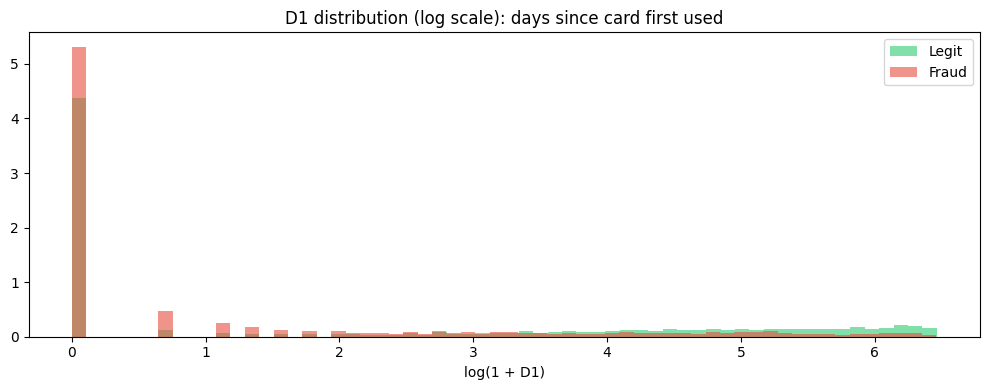

In [11]:
d_cols = [c for c in train.columns if c.startswith('D') and c[1:].isdigit()]
print(f'D columns available: {d_cols}')

d_corr = (train[d_cols + ['isFraud']]
          .corr()['isFraud']
          .drop('isFraud')
          .abs()
          .sort_values(ascending=False))
print('\nD column correlation with isFraud (absolute):')
print(d_corr.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log1p(train[train.isFraud == 0]['D1'].dropna()),
        bins=60, alpha=0.6, color='#2ecc71', label='Legit', density=True)
ax.hist(np.log1p(train[train.isFraud == 1]['D1'].dropna()),
        bins=60, alpha=0.6, color='#e74c3c', label='Fraud', density=True)
ax.set_title('D1 distribution (log scale): days since card first used')
ax.set_xlabel('log(1 + D1)')
ax.legend()
plt.tight_layout()
plt.show()


## 10. V Columns: Vesta Engineered Features

The V columns (V1 through V339) are features engineered by Vesta Corporation
and are anonymized for security. They appear to represent risk scores,
velocity counts, and behavioral signals computed by Vesta's internal systems.

We identify the top predictors by correlation with the fraud label and use
this to prioritize which V columns to include in our feature set.


Total V columns: 339

Top 20 V columns by correlation with isFraud:
V257   0.38
V246   0.37
V244   0.36
V242   0.36
V201   0.33
V200   0.32
V189   0.31
V188   0.30
V258   0.30
V45    0.28
V158   0.28
V156   0.28
V149   0.27
V228   0.27
V44    0.26
V86    0.25
V87    0.25
V170   0.25
V147   0.24
V52    0.24


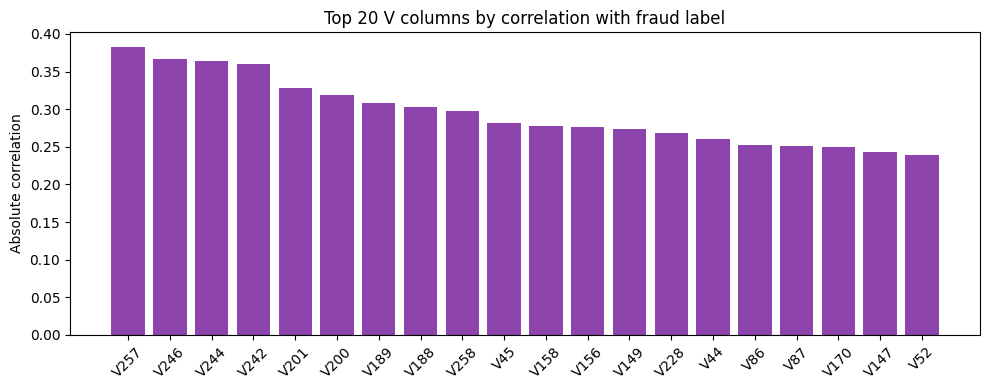

In [12]:
v_cols = [c for c in train.columns if c.startswith('V')]
print(f'Total V columns: {len(v_cols)}')

v_corr = (train[v_cols + ['isFraud']]
          .corr()['isFraud']
          .drop('isFraud')
          .abs()
          .sort_values(ascending=False))

print('\nTop 20 V columns by correlation with isFraud:')
print(v_corr.head(20).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
top20 = v_corr.head(20)
ax.bar(top20.index, top20.values, color='#8e44ad')
ax.set_title('Top 20 V columns by correlation with fraud label')
ax.set_ylabel('Absolute correlation')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## 11. Identity Table: Device and Browser

The identity file is only available for about 40% of transactions.
Interestingly, transactions WITH identity information actually show a higher
fraud rate than those without. This is counterintuitive but makes sense
because identity data is more commonly available for online transactions,
which are also more commonly targeted by fraudsters than in-person purchases.


In [13]:
print(f'Transactions with identity info: {train_id.TransactionID.nunique():,}')
print(f'Transactions without           : {train_txn.shape[0] - train_id.shape[0]:,}')
print()

train['has_identity'] = train['TransactionID'].isin(train_id['TransactionID']).astype(int)
print('Fraud rate WITH identity info   :',
      f"{train[train.has_identity == 1]['isFraud'].mean() * 100:.2f}%")
print('Fraud rate WITHOUT identity info:',
      f"{train[train.has_identity == 0]['isFraud'].mean() * 100:.2f}%")

if 'DeviceType' in train.columns:
    print('\n=== Fraud rate by device type ===')
    print(train.groupby('DeviceType')['isFraud'].agg(['count', 'mean'])
          .assign(fraud_pct=lambda x: (x['mean'] * 100).round(2))
          .drop('mean', axis=1).to_string())


Transactions with identity info: 144,233
Transactions without           : 446,307

Fraud rate WITH identity info   : 7.85%
Fraud rate WITHOUT identity info: 2.09%

=== Fraud rate by device type ===
            count  fraud_pct
DeviceType                  
desktop     85165       6.52
mobile      55645      10.17


## 12. Key Findings Summary

This section summarizes the patterns that directly motivated feature engineering decisions.
Each finding below maps to one or more features built in features.py.


In [14]:
print('=' * 55)
print('EDA SUMMARY: KEY FINDINGS')
print('=' * 55)

print(f"""
Dataset
  Rows         : {train.shape[0]:,}
  Columns      : {train.shape[1]}
  Fraud rate   : {train.isFraud.mean()*100:.2f}%
  Imbalance    : {round((train.isFraud==0).sum()/train.isFraud.sum(),1)} to 1

Missing values
  Cols >90% missing : {(missing > 90).sum()}
  Cols >50% missing : {(missing > 50).sum()}

Amount
  Fraud avg    : \${fraud.TransactionAmt.mean():.2f}
  Legit avg    : \${legit.TransactionAmt.mean():.2f}

Time
  Peak fraud hour  : {fraud_by_hour.idxmax()}:00  ({fraud_by_hour.max():.1f}% fraud rate)
  Lowest fraud hour: {fraud_by_hour.idxmin()}:00  ({fraud_by_hour.min():.1f}% fraud rate)

Email domains
  Highest fraud rate: mail.com at 18.9%
  Dataset average   : {train.isFraud.mean()*100:.1f}%

Card age (D1)
  Fraud transactions heavily concentrated at D1 = 0
  Stolen cards are used immediately after compromise

Feature engineering implications
  amt_z_score_card  : amount deviation from card history
  card_age          : D1 as days since card first used
  is_new_card       : card_age < 30 binary flag
  hour              : extract from TransactionDT
  is_night          : binary flag for hours 0 to 6
  P_emaildomain     : target encoded by historical fraud rate
""")


EDA SUMMARY: KEY FINDINGS

Dataset
  Rows         : 590,540
  Columns      : 437
  Fraud rate   : 3.50%
  Imbalance    : 27.6 to 1

Missing values
  Cols >90% missing : 12
  Cols >50% missing : 214

Amount
  Fraud avg    : \$149.24
  Legit avg    : \$134.51

Time
  Peak fraud hour  : 7:00  (10.6% fraud rate)
  Lowest fraud hour: 13:00  (2.3% fraud rate)

Email domains
  Highest fraud rate: mail.com at 18.9%
  Dataset average   : 3.5%

Card age (D1)
  Fraud transactions heavily concentrated at D1 = 0
  Stolen cards are used immediately after compromise

Feature engineering implications
  amt_z_score_card  : amount deviation from card history
  card_age          : D1 as days since card first used
  is_new_card       : card_age < 30 binary flag
  hour              : extract from TransactionDT
  is_night          : binary flag for hours 0 to 6
  P_emaildomain     : target encoded by historical fraud rate

